In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

Cloning into 'network-simulator'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 41 (delta 29), reused 15 (delta 9), pack-reused 0
Receiving objects: 100% (41/41), 20.76 KiB | 10.38 MiB/s, done.
Resolving deltas: 100% (29/29), done.


## 1章

### 演習課題1: 簡単なネットワークの構築と可視化

#### サンプルコード
```python
# 必要なクラスをインポート
from sec1.NetworkGraph import NetworkGraph
from sec1.Node import Node
from sec1.Link import Link

# ネットワークグラフのインスタンスを作成
network_graph = NetworkGraph()

# ノードを作成
node1 = Node(node_id=1, address="00:01", network_graph=network_graph)
node2 = Node(node_id=2, address="00:02", network_graph=network_graph)

# リンクを作成し、ノードを接続
link = Link(node1, node2, network_graph=network_graph)

# グラフを描画
network_graph.draw()
```

#### 解説
このコードでは、2つのノード（`Node 1` と `Node 2`）を作成し、これらをリンクで接続し、グラフを可視化しています。

### 演習課題2: パケットの送受信

#### サンプルコード
```python
# パケットクラスをインポート
from sec1.NetworkGraph import NetworkGraph
from sec1.Node import Node
from sec1.Link import Link
from sec1.Packet import Packet

# ネットワークグラフのインスタンスを作成
network_graph = NetworkGraph()

# ノードを作成
node1 = Node(node_id=1, address="00:01", network_graph=network_graph)
node2 = Node(node_id=2, address="00:02", network_graph=network_graph)

# リンクを作成し、ノードを接続
link = Link(node1, node2, network_graph=network_graph)

# グラフを描画
network_graph.draw()

# パケットを作成
packet = Packet("Hello, World!", node1, node2)

# パケットを送信
node1.send_packet(packet)
```

#### 解説
このコードでは、まずノード間で送信するパケットを作成します。その後、`node1` から `node2` へパケットを送信し、`node2` で受信したパケットの内容を表示しています。このプロセスを通じて、パケットがどのようにノード間で転送されるかを理解することができます。

### 演習課題3: ネットワークの拡張

#### サンプルコード
```python
from sec1.NetworkGraph import NetworkGraph
from sec1.Node import Node
from sec1.Link import Link

network_graph = NetworkGraph()

# ノードを作成
node1 = Node(node_id=1, address="00:01", network_graph=network_graph)
node2 = Node(node_id=2, address="00:02", network_graph=network_graph)
node3 = Node(node_id=3, address="00:03", network_graph=network_graph)
node4 = Node(node_id=4, address="00:04", network_graph=network_graph)

# リンクを作成し、ノードを接続
link1 = Link(node1, node2, network_graph=network_graph)
link2 = Link(node1, node3, network_graph=network_graph)
link3 = Link(node2, node3, network_graph=network_graph)
link4 = Link(node3, node4, network_graph=network_graph)

# グラフを描画
network_graph.draw()
```

#### 解説
このコードでは、追加のノード（`Node 3`, `Node 4`）とリンク（`link1`, `link2`, `link3`, `link4`）を作成し、4つのノードでネットワークを構築しています。次に、ネットワークのグラフを作成し可視化しています。


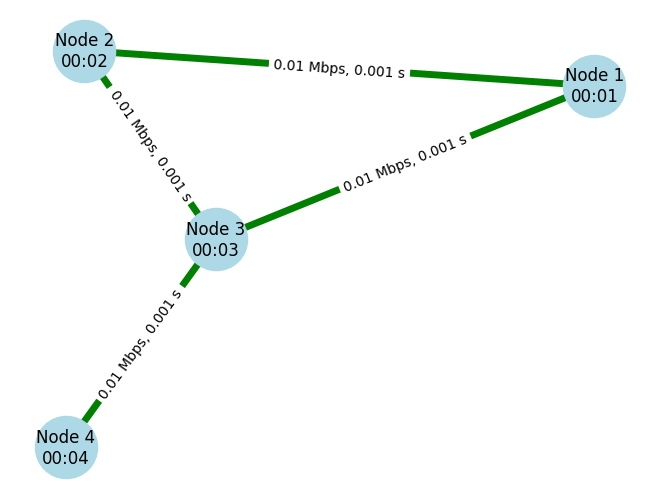

In [ ]:
from sec1.NetworkGraph import NetworkGraph
from sec1.Node import Node
from sec1.Link import Link

network_graph = NetworkGraph()

# ノードを作成
node1 = Node(node_id=1, address="00:01", network_graph=network_graph)
node2 = Node(node_id=2, address="00:02", network_graph=network_graph)
node3 = Node(node_id=3, address="00:03", network_graph=network_graph)
node4 = Node(node_id=4, address="00:04", network_graph=network_graph)

# リンクを作成し、ノードを接続
link1 = Link(node1, node2, network_graph=network_graph)
link2 = Link(node1, node3, network_graph=network_graph)
link3 = Link(node2, node3, network_graph=network_graph)
link4 = Link(node3, node4, network_graph=network_graph)

# グラフを描画
network_graph.draw()


## 2章

### 演習課題1: パケット転送時間の計算

#### シナリオスクリプト
```python
from sec2.NetworkEventScheduler import NetworkEventScheduler
from sec2.Node import Node
from sec2.Link import Link
from sec2.Packet import Packet

# サンプルシナリオの設定
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=True)

# 結果を格納するためのリスト
transfer_times = []

# 異なる帯域幅でのシミュレーション
for bandwidth in [10000, 50000, 100000]:
    # ノードとリンクの設定
    node1 = Node(node_id=1, address="00:01", network_event_scheduler=network_event_scheduler)
    node2 = Node(node_id=2, address="00:02", network_event_scheduler=network_event_scheduler)
    link1 = Link(node1, node2, bandwidth=bandwidth, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

    # パケットサイズ（バイト）
    packet_size = 1000

    # パケット転送時間の計算
    transfer_time = (packet_size * 8) / bandwidth

    # パケットを作成し、送信
    packet = Packet(source="00:01", destination="00:02", header_size=40, payload_size=packet_size - 40, network_event_scheduler=network_event_scheduler)
    node1.send_packet(packet)

    # シミュレーションの実行
    network_event_scheduler.run()

    # 結果の格納
    transfer_times.append((bandwidth, transfer_time))

# 結果の表示
for bandwidth, time in transfer_times:
    print(f"帯域幅: {bandwidth} bps, 転送時間: {time:.5f} 秒")
```

このコードでは、異なる帯域幅（10kbps, 50kbps, 100kbps）を設定し、1000バイトのパケットをそれぞれの帯域幅で送信します。シミュレーションを実行した後、転送時間を計算しリストに格納します。最後に、それぞれの帯域幅に対する転送時間を出力します。帯域幅が大きくなるほど、転送時間が短くなることを確認しましょう。

### 演習課題2: ネットワークの遅延とスループットの測定

#### シナリオスクリプト
```python
from sec2.NetworkEventScheduler import NetworkEventScheduler
from sec2.Node import Node
from sec2.Link import Link

# 異なる条件でのシミュレーション
for delay in [0.001, 0.005, 0.01]:
    for bandwidth in [10000, 50000, 100000]:
        # ネットワークの設定
        network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=False)
        node1 = Node(node_id=1, address="00:01", network_event_scheduler=network_event_scheduler)
        node2 = Node(node_id=2, address="00:02", network_event_scheduler=network_event_scheduler)
        link1 = Link(node1, node2, bandwidth=bandwidth, delay=delay, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

        # トラフィックの設定
        node1.set_traffic(destination="00:02", bitrate=100000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=40, payload_size=1000)

        # シミュレーションの実行
        network_event_scheduler.run()

        # 結果の計算と出力
        network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
```

このコードは、異なるネットワーク条件（帯域幅と遅延）下でシミュレーションを実行し、それぞれの条件でのネットワークパフォーマンス（遅延、スループット、パケットロスなど）を測定するものです。条件は一例なので、パラメタが異なっても構いません。リンク帯域や遅延が変わったときに、ログがどうなるかを確認しましょう。

### 演習課題3: ネットワークの混雑とパケットロスのシミュレーション

#### シナリオスクリプト
```python
from sec2.NetworkEventScheduler import NetworkEventScheduler
from sec2.Node import Node
from sec2.Link import Link

# パケットロス率を変更してシミュレーション
loss_rates = [0.0, 0.05, 0.1, 0.15]

for loss_rate in loss_rates:
    # ネットワークの設定
    network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=False)
    node1 = Node(node_id=1, address="00:01", network_event_scheduler=network_event_scheduler)
    node2 = Node(node_id=2, address="00:02", network_event_scheduler=network_event_scheduler)
    link1 = Link(node1, node2, bandwidth=100000, delay=0.001, loss_rate=loss_rate, network_event_scheduler=network_event_scheduler)

    # トラフィックの設定
    node1.set_traffic(destination="00:02", bitrate=100000, start_time=1.0, duration=100.0, burstiness=1.0, header_size=40, payload_size=1000)

    # シミュレーションの実行
    network_event_scheduler.run()

    # 結果の計算と出力
    network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)    
```

`Link1`におけるパケットロス率を変化させて、結果をprintして確認するコードです。
ビットレートや測定時間を増やして送信パケット数を増加させた方が、統計的に安定した結果が得られます。
ロス率が大きくなるほど、実際にパケットロス数が大きくなることを確認しましょう。


## 3章

### 演習課題1: ネットワーク構築とMACアドレス設定

#### サンプルコード
```python
from sec3b.NetworkEventScheduler import NetworkEventScheduler
from sec3b.Node import Node
from sec3b.Switch import Switch
from sec3b.Link import Link

# ネットワークイベントスケジューラの設定
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=True)

# ノードとスイッチの作成
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", network_event_scheduler=network_event_scheduler)
node3 = Node(node_id="n3", mac_address="00:1A:2B:3C:4D:60", network_event_scheduler=network_event_scheduler)
node4 = Node(node_id="n4", mac_address="00:1A:2B:3C:4D:61", network_event_scheduler=network_event_scheduler)
switch1 = Switch(node_id="s1", network_event_scheduler=network_event_scheduler)
switch2 = Switch(node_id="s2", network_event_scheduler=network_event_scheduler)

# ノードとスイッチをリンクで接続
link1 = Link(node1, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(node2, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link3 = Link(node3, switch2, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link4 = Link(node4, switch2, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link5 = Link(switch1, switch2, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# ネットワークのトポロジを描画
network_event_scheduler.draw()
```

スイッチとノードを作成し、それらをリンクで接続してネットワークを構築します。各ノードには一意のMACアドレスが割り当てられます。

### 演習課題2: フォワーディングテーブルの作成

#### サンプルコード
```python
# スイッチのフォワーディングテーブルを設定
switch1.update_forwarding_table(node1.mac_address, link1)
switch1.update_forwarding_table(node2.mac_address, link2)
switch1.update_forwarding_table(node3.mac_address, link5)
switch1.update_forwarding_table(node4.mac_address, link5)
switch2.update_forwarding_table(node1.mac_address, link5)
switch2.update_forwarding_table(node2.mac_address, link5)
switch2.update_forwarding_table(node3.mac_address, link3)
switch2.update_forwarding_table(node4.mac_address, link4)
```

スイッチのフォワーディングテーブルを設定します。
各スイッチは、MACアドレスが自身のどのリンクの先に存在するか、だけを認識すると考えてください。
正しく設定できれば、スイッチはネットワーク内でパケットを適切に転送できるようになります。

### 演習課題3: パケット転送のシミュレーション

#### サンプルコード
```python
# 通信アプリケーションの設定
node1.set_traffic(destination_mac="00:1A:2B:3C:4D:61", bitrate=1000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=40, payload_size=1000)

# イベントスケジューラを実行してネットワークの動作をシミュレート
network_event_scheduler.run()

# 結果を確認
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)
```

実際にノード間でトラフィック（パケット転送）を設定し、シミュレーションを実行してネットワークの動作を確認します。
その後、パケットの流れとパフォーマンスを確認します。


## 4章

### 演習課題1: 複数スイッチを用いたネットワーク構築

```
from sec4b.NetworkEventScheduler import NetworkEventScheduler
from sec4b.Node import Node
from sec4b.Switch import Switch
from sec4b.Link import Link

network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=False, stp_verbose=True)

# ノードとスイッチの設定
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", network_event_scheduler=network_event_scheduler)
switch1 = Switch(node_id="s2", network_event_scheduler=network_event_scheduler)
switch2 = Switch(node_id="s20", network_event_scheduler=network_event_scheduler)
switch3 = Switch(node_id="s200", network_event_scheduler=network_event_scheduler)
switch4 = Switch(node_id="s15", network_event_scheduler=network_event_scheduler)
switch5 = Switch(node_id="s150", network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(switch1, switch2, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link3 = Link(switch1, switch3, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link4 = Link(switch1, switch4, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link5 = Link(switch2, switch3, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link6 = Link(switch2, switch4, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link7 = Link(switch3, switch4, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link8 = Link(node2, switch3, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link9 = Link(switch5, switch2, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link10 = Link(switch5, switch4, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# ネットワークのトポロジを描画
network_event_scheduler.draw()
```

この課題では、複数のスイッチとノードを使用してローカルネットワークを構築します。ネットワークのトポロジを描画することで、物理的な接続とネットワークの構造を視覚的に確認できます。このプロセスを通じて、ネットワークの基本的な接続方法と物理的なトポロジの概念を学びます。

### 演習課題2: STPの確認

```
# イベントスケジューラを実行
network_event_scheduler.run()

# 結果を確認
# リンクの状態を確認
switch1.print_link_states()
switch2.print_link_states()
switch3.print_link_states()
switch4.print_link_states()
switch5.print_link_states()
# リンクの状態を可視化
switches = [switch1, switch2, switch3, switch4, switch5]
network_event_scheduler.draw_with_link_states(switches)

# フォワーディングテーブルを確認
switch1.print_forwarding_table()
switch2.print_forwarding_table()
switch3.print_forwarding_table()
switch4.print_forwarding_table()
switch5.print_forwarding_table()
```

この課題では、スパニングツリープロトコル（STP）の動作を観察します。STPはネットワーク内でのループを防止し、冗長性を確保するために使用されます。イベントスケジューラを実行することで、各スイッチのリンク状態がどのように設定されるかを確認し、STPがネットワークの安定性と効率性をどのように向上させるかを理解します。

### 演習課題3: パケット送受信とフォワーディングテーブルの観察

```
# 通信アプリケーションの設定
node1.set_traffic(destination_mac="00:1A:2B:3C:4D:5F", bitrate=10000, start_time=1.0, duration=5.0, burstiness=1.0, header_size=40, payload_size=85)

# イベントスケジューラを実行
network_event_scheduler.run()

# ネットワーク上でのパケットの流れとパフォーマンスに関するサマリを生成
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)
```

この課題では、ノード間でパケット送受信を行い、スイッチのフォワーディングテーブルの動作を観察します。通信アプリケーションを設定し、イベントスケジューラを実行することで、ネットワーク上でのパケットの流れとパフォーマンスに関するサマリを生成し、ネットワークの動作を理解することができます。このプロセスは、スイッチの基本的な機能とパケット転送の原理を学ぶ上で重要です。


## 5章

### 演習課題1: ネットワーク設定の誤りの特定と修正

#### サンプルコード（修正後）
```python
# 正しいネットワーク設定
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", ip_address="192.168.1.10/24", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", ip_address="192.168.2.10/24", network_event_scheduler=network_event_scheduler)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(router1, node2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
```

#### 解説
元の設定では、`node1` と `router1` が異なるサブネットに属していました。修正後、`node1` は `192.168.1.10/24` に設定され、`router1` の一つのインターフェースと同じサブネット内にあります。同様に、`node2` と `router1` のもう一つのインターフェースも同じサブネット `192.168.2.0/24` に属しています。
なお本課題では、ノードのIPアドレスに合わせてルータ側のIPアドレスを修正しても問題ありません。

### 演習課題2: ルーティングテーブルの設定

#### サンプルコード
```python
# ルータ r1 のルーティングテーブルを設定
router1.add_route("192.168.1.0/24", None, link1)  # node1 への直接ルート
router1.add_route("192.168.2.0/24", None, link2)  # node2 への直接ルート

# イベントスケジューラを実行
network_event_scheduler.run()
```

#### 解説
このコードでは、`router1` に2つのルートを設定しています。これらのルートは、`node1` と `node2` への直接接続を示しています。ルーティングテーブルにより、`router1` は送信元から宛先へのパケット転送を適切に行うことができます。

### 演習課題3: パケット送受信とフォワーディングテーブルの観察

#### サンプルコード
```python
# 通信アプリケーションの設定
node1.set_traffic(destination_mac="00:1A:2B:3C:4D:5F", destination_ip="192.168.2.10", bitrate=100000, start_time=1.0, duration=10.0, header_size=50, payload_size=1000, burstiness=1.0)

# イベントスケジューラを再度実行
network_event_scheduler.run()

# ネットワーク上でのパケットの流れとパフォーマンスに関するサマリを生成
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)
```

#### 解説
このコードでは、`node1` から `node2` へのトラフィックを生成し、パケット転送のプロセスをシミュレートしています。`router1` は設定されたルーティングテーブルに基づき、パケットを適切に転送します。イベントスケジューラの実行後、パケットの流れ、ネットワークのスループット、および遅延のサマリを生成して、ネットワークのパフォーマンスを観察できます。


## 6章

### 演習課題1

以下のようなコードを書いてシミュレーションを実行します。
ログを丁寧に読んで、OSPFの動作を確認しましょう。

```
from sec6c.NetworkEventScheduler import NetworkEventScheduler
from sec6c.Node import Node
from sec6c.Router import Router
from sec6c.Link import Link

# routing_verbose=Trueでルーティング関連情報を出力
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=True)

# ノードとルータの設定
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", ip_address="192.168.1.10/24", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", ip_address="192.168.2.10/24", network_event_scheduler=network_event_scheduler)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.1/24", "10.0.0.1/30"], network_event_scheduler=network_event_scheduler)
router2 = Router(node_id="r2", ip_addresses=["192.168.2.1/24", "10.0.0.2/30"], network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(node2, router2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link3 = Link(router1, router2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# 通信アプリケーションの設定
node1.set_traffic(destination_mac="00:1A:2B:3C:4D:5F", destination_ip="192.168.2.10/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# イベントスケジューラを実行
network_event_scheduler.run_until(20.0)

# ルーティングテーブルの確認
router1.print_routing_table()
router2.print_routing_table()

# ノードから宛先IPアドレスまでの経路を出力して確認
node1.print_route("192.168.2.10/24")

# 結果を確認
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)
```

### 演習課題2

OSPFは、リンクステートルーティングプロトコルの一種であり、ネットワーク内の各ルータがリンクの状態（帯域幅、遅延、負荷など）を把握し、最短経路の計算に利用することができます。OSPFでは、全ルータが同じトポロジ情報を持つため、各ルータは独立して最短経路を計算できます。

手動でのルーティング設定では、ネットワーク管理者が各ルータのルーティングテーブルを直接設定する必要があります。これは、小規模なネットワークでは実行可能ですが、ネットワークの規模が大きくなると、複雑性が増し、誤設定のリスクが高まります。一方、OSPFによる自動ルート設定では、ネットワークの変更があった場合に自動的に最適なルートが計算され、更新されるため、ネットワークの柔軟性と耐障害性が向上します。

### 演習課題3

OSPFにおいて、リンクコストはそのリンクを通過する際の"コスト"を表します。通常、リンクコストはリンクの帯域幅に基づいて計算され、帯域幅が高いほどコストは低くなります。このコストは、OSPFが最短経路を計算する際の重要な要素です。

リンクのコストを変更すると、OSPFによる経路選択が変化する可能性があります。特定のリンクのコストが低下すると、そのリンクを通過する経路を優先するようになります。逆に、リンクのコストが上昇すると、そのリンクを避ける経路が選択されるようになります。

リンクコストを変更することで、OSPFがどのように経路を選択するかを観察することは、ネットワーク設計と管理において重要です。例えば、ネットワークの特定の部分に過剰なトラフィックが集中している場合、そのリンクのコストを敢えて増加させることで、トラフィックの再分散を促すことができます。


## 7章

### 演習課題1

以下のように設定します。

```
# ARPテーブル
# node1
node1.add_to_arp_table(node2.ip_address, router1.get_mac_address(link1b))
node1.add_to_arp_table(node3.ip_address, router1.get_mac_address(link1b))
# node2
node2.add_to_arp_table(node1.ip_address, router2.get_mac_address(link2b))
node2.add_to_arp_table(node3.ip_address, router2.get_mac_address(link2b))
# node3
node3.add_to_arp_table(node1.ip_address, router3.get_mac_address(link3b))
node3.add_to_arp_table(node2.ip_address, router3.get_mac_address(link3b))
# router1
router1.add_to_arp_table(node1.ip_address,node1.mac_address)
router1.add_to_arp_table(node2.ip_address,router2.get_mac_address(link4a))
router1.add_to_arp_table(node3.ip_address,router3.get_mac_address(link4c))
# router2
router2.add_to_arp_table(node1.ip_address,router1.get_mac_address(link4a))
router2.add_to_arp_table(node2.ip_address,node2.mac_address)
router2.add_to_arp_table(node3.ip_address,router3.get_mac_address(link4b))
# router3
router3.add_to_arp_table(node1.ip_address,router1.get_mac_address(link4c))
router3.add_to_arp_table(node2.ip_address,router2.get_mac_address(link4b))
router3.add_to_arp_table(node3.ip_address,node3.mac_address)
```

### 演習課題2

`Router`クラスのコードから、以下の処理を見つけて、その周辺にコードを追記するなどして確認してみましょう。

- MACヘッダの除去

```
    def receive_packet(self, packet, received_link):

            省略

            if packet.header["destination_mac"] == self.get_mac_address(received_link):
                    self.network_event_scheduler.log_packet_info(packet, "received", self.node_id)  # パケット受信をログに記録
                    packet.remove_mac_header()  # MACヘッダを疑似的に除去

```

- MACヘッダの付与

```
    def process_and_enqueue_packet(self, packet, link):
        # パケットのMACアドレスを更新
        source_mac = self.get_mac_address(link)
        destination_mac = self.get_mac_address_from_ip(packet.header["destination_ip"])
        packet.add_mac_header(source_mac, destination_mac)
        
        # パケットの転送情報をログに記録
        self.network_event_scheduler.log_packet_info(packet, "forwarded", self.node_id)
        
        # パケットをリンクのキューに追加
        link.enqueue_packet(packet, self)
```




## 8章

### 演習課題1

例えば、以下のようなログが出力されます。
ARPパケットが、どのノード間で、どのようなタイミングで送受信されているのかを確認できます。

```
Time: 1.0 Node: n1, Event: ARP request, Packet: b9859d58-e604-46a1-9366-bf9faae8d4b7, Src: 192.168.1.1/24, Dst: 192.168.1.2/24
Time: 1.0 Node: n2, Event: ARP request, Packet: 8590722a-64a3-4a30-96d5-619fd0a70c68, Src: 192.168.1.2/24, Dst: 192.168.1.3/24
Time: 1.0 Node: n3, Event: ARP request, Packet: 28b73cf3-6211-4417-b924-7d5c0c6292c9, Src: 192.168.1.3/24, Dst: 192.168.1.4/24
Time: 1.0 Node: n4, Event: ARP request, Packet: ed7cda22-cbc0-4d56-90fa-d3b888fd1c31, Src: 192.168.1.4/24, Dst: 192.168.1.1/24

Time: 1.02 Node: n2, Event: ARP reply, Packet: 646e3b02-b8a7-454c-831a-c24778f91c88, Src: 192.168.1.2/24, Dst: 192.168.1.1/24
Time: 1.02224 Node: n3, Event: ARP reply, Packet: 5f377210-b773-4afa-ac15-64f88c1d1a79, Src: 192.168.1.3/24, Dst: 192.168.1.2/24
Time: 1.02448 Node: n4, Event: ARP reply, Packet: 96004725-4482-40dd-a497-9c6b9989b393, Src: 192.168.1.4/24, Dst: 192.168.1.3/24
Time: 1.02896 Node: n1, Event: ARP reply, Packet: 692b123a-f9d3-4ddf-800b-351aa6d1655e, Src: 192.168.1.1/24, Dst: 192.168.1.4/24

Time: 1.04 Node: n1, Event: ARP reply received, Packet: 646e3b02-b8a7-454c-831a-c24778f91c88, Src: 192.168.1.2/24, Dst: 192.168.1.1/24
Time: 1.04224 Node: n2, Event: ARP reply received, Packet: 5f377210-b773-4afa-ac15-64f88c1d1a79, Src: 192.168.1.3/24, Dst: 192.168.1.2/24
Time: 1.04448 Node: n3, Event: ARP reply received, Packet: 96004725-4482-40dd-a497-9c6b9989b393, Src: 192.168.1.4/24, Dst: 192.168.1.3/24
Time: 1.0489600000000001 Node: n4, Event: ARP reply received, Packet: 692b123a-f9d3-4ddf-800b-351aa6d1655e, Src: 192.168.1.1/24, Dst: 192.168.1.4/24
```

### 演習課題2

例えば、以下のように設定します。

```
dns1.add_dns_record("www.example.com", "192.168.1.1/24")
dns1.add_dns_record("service.example.net", "192.168.1.2/24")
dns1.add_dns_record("api.example.org", "192.168.1.3/24")
```

### 演習課題3

例えば、以下のようなログが出力されます。
どのノード間で、どういた順番でDNSパケットが送受信されているか、といったことを確認できます。

```
Time: 1.0 Node: n1, Event: DNS query, Packet: 0813776d-d817-4aa5-afcd-59023f060b39, Src: 192.168.1.1/24, Dst: 192.168.1.200/24

Time: 1.02 Node: dns1, Event: DNS query received, Packet: 0813776d-d817-4aa5-afcd-59023f060b39, Src: 192.168.1.1/24, Dst: 192.168.1.200/24
Time: 1.02 Node: dns1, Event: DNS response, Packet: 1a4cff3e-f64b-46bb-837d-f8bfa6acd012, Src: 192.168.1.200/24, Dst: 192.168.1.1/24

Time: 1.04 Node: n1, Event: DNS packet received, Packet: 1a4cff3e-f64b-46bb-837d-f8bfa6acd012, Src: 192.168.1.200/24, Dst: 192.168.1.1/24
n1 DNS record added: www.example.com -> 192.168.2.1/24
```



## 9章

### 演習課題1

例えば、以下のようなログが出力されます。
DHCPのDiscover、Offer、Request、Ackの各パケットが交換されることでIPアドレスが動的に設定される処理をトレースできます。

```
Time: 0.5822448512879713 Node: n1, Event: DHCP Discover sent, Packet: 9eef68b1-7fd3-4702-bff1-a7121f73c3ec, Src: 0.0.0.0/32, Dst: 255.255.255.255/32

Time: 0.6022448512879713 Node: dhcp1, Event: DHCP Offer, Packet: 3b9baccf-7e82-4b7e-9848-851a51e38401, Src: 192.168.1.250/24, Dst: 192.168.1.1/24

Time: 0.6222448512879714 Node: n1, Event: DHCP Offer received, Packet: 3b9baccf-7e82-4b7e-9848-851a51e38401, Src: 192.168.1.250/24, Dst: 192.168.1.1/24
Time: 0.6222448512879714 Node: n1, Event: DHCP Request sent, Packet: 054bf29c-e156-4569-8ad8-aee165a56d1d, Src: 0.0.0.0/32, Dst: 255.255.255.255/32

Time: 0.6622448512879714 Node: n1, Event: DHCP ACK received, Packet: 9dc709c8-ab8b-4039-a648-7a28ca0832f1, Src: 192.168.1.250/24, Dst: 192.168.1.1/24
Node n1 has been assigned the IP address 192.168.1.1/24.
Node n1 has been assigned the DNS server IP address 192.168.1.200/24.
```

### 演習課題2

例えば、以下のようなログが出力されます。
NATテーブルを用いて、内部アドレスと外部アドレスの変換処理が行われています。

```
Time: 1.1 Node: r1, Event: NAT outbound: 192.168.1.1 -> 10.0.0.1, Packet: c8061637-c2b0-4d70-98f6-1afb95700545, Src: 192.168.1.1, Dst: 10.0.0.2/24
```


## 10章

### 演習課題1

例えば、以下のようなログが出力されます。
3ウェイハンドシェイクでは、SYN、SYN-ACK、ACKの各フラグをTrueにしたパケットが交換されることで、相互にコネクションを確立します。

```
Initiating TCP handshake: Sending SYN to 192.168.2.1/24:3818 from port 3285
TCP connection state updated to SYN_SENT for 192.168.2.1/24:3818
Sending SYN-ACK to 192.168.1.1/24:3285
Sending ACK to 192.168.2.1/24:3818, Final ACK: True
Establishing TCP connection with 192.168.2.1/24:3818
TCP connection state updated to ESTABLISHED for 192.168.2.1/24:3818
Establishing TCP connection with 192.168.1.1/24:3285
TCP connection state updated to ESTABLISHED for 192.168.1.1/24:3285
```

### 演習課題2

例えば、以下のようなログが出力されます。
IPアドレスとポート番号の組み合わせによって、通信トラフィックが識別されます。
なおシミュレーションの簡易化のため、ポート番号は単純にランダムに設定される点にはご留意ください。

```
アクティブなTCPコネクションの状態:
宛先IP: 192.168.2.1/24, 宛先ポート: 3818, 状態: ESTABLISHED
```


## 11章

### 演習課題1

例えば、`payload_size`を100にしたとき、以下のようなログが出力されます。
シーケンス番号は100ずつ増加しており、それに対応した値がACKとして返送されてくることが分かります。
このように、送信するデータサイズに応じたシーケンス番号を付与することで、どのデータを送信したかを識別できます。

```
Sending TCP packet from n1 to 192.168.2.1/24:5693 with Flags: PSH, Data Length: 100, Sequence Number: 10148, Acknowledgment Number: 8747,
Updated ACK number to 10248 for connection ('192.168.1.1/24', 19737).
Sending TCP packet from n2 to 192.168.1.1/24:19737 with Flags: ACK, Data Length: 0, Sequence Number: 8747, Acknowledgment Number: 10248,
Sending TCP packet from n1 to 192.168.2.1/24:5693 with Flags: PSH, Data Length: 100, Sequence Number: 10248, Acknowledgment Number: 8747,
Updated ACK number to 10348 for connection ('192.168.1.1/24', 19737).
Sending TCP packet from n2 to 192.168.1.1/24:19737 with Flags: ACK, Data Length: 0, Sequence Number: 8747, Acknowledgment Number: 10348,
Sending TCP packet from n1 to 192.168.2.1/24:5693 with Flags: PSH, Data Length: 100, Sequence Number: 10348, Acknowledgment Number: 8747,
```

### 演習課題2

例えば、以下のようなログが出力されます。
ロス率を0に設定したとき、再送制御は行われていません。

```
Initiating TCP handshake: Sending SYN to 192.168.2.1/24:8033 from port 44163
Sending TCP packet from n1 to 192.168.2.1/24:8033 with Flags: SYN, Data Length: 0, Sequence Number: 7345, Acknowledgment Number: 0,
Connection state updated to SYN_SENT for 192.168.2.1/24:8033
Sending TCP packet from n2 to 192.168.1.1/24:44163 with Flags: SYN,ACK, Data Length: 0, Sequence Number: 4685, Acknowledgment Number: 7346,
TCP connection state updated to ESTABLISHED for ('192.168.1.1/24', 44163)
TCP connection state updated to ESTABLISHED for ('192.168.2.1/24', 8033)
Sending TCP packet from n1 to 192.168.2.1/24:8033 with Flags: ACK, Data Length: 0, Sequence Number: 7346, Acknowledgment Number: 4686,
Sending TCP packet from n1 to 192.168.2.1/24:8033 with Flags: PSH, Data Length: 1000, Sequence Number: 7346, Acknowledgment Number: 4686,
Sending TCP packet from n1 to 192.168.2.1/24:8033 with Flags: PSH, Data Length: 1000, Sequence Number: 8346, Acknowledgment Number: 4686,
Sending TCP packet from n1 to 192.168.2.1/24:8033 with Flags: PSH, Data Length: 1000, Sequence Number: 9346, Acknowledgment Number: 4686,
Sending TCP packet from n1 to 192.168.2.1/24:8033 with Flags: PSH, Data Length: 1000, Sequence Number: 10346, Acknowledgment Number: 4686,
No traffic info found for ('192.168.1.1/24', 44163)
Received sequence number: 7346, payload length: 1000, current ACK number: 7346
Updated ACK number to 8346 for connection ('192.168.1.1/24', 44163).
Sending TCP packet from n2 to 192.168.1.1/24:44163 with Flags: ACK, Data Length: 0, Sequence Number: 4686, Acknowledgment Number: 8346,
Removing packet with sequence number 7346 from window for connection ('192.168.2.1/24', 8033) due to receiving ACK 8346. Expected ACK was 8346.
Sending TCP packet from n1 to 192.168.2.1/24:8033 with Flags: PSH, Data Length: 1000, Sequence Number: 11346, Acknowledgment Number: 4686,
Received sequence number: 8346, payload length: 1000, current ACK number: 8346
Updated ACK number to 9346 for connection ('192.168.1.1/24', 44163).
Sending TCP packet from n2 to 192.168.1.1/24:44163 with Flags: ACK, Data Length: 0, Sequence Number: 4686, Acknowledgment Number: 9346,
Removing packet with sequence number 8346 from window for connection ('192.168.2.1/24', 8033) due to receiving ACK 9346. Expected ACK was 9346.
Sending TCP packet from n1 to 192.168.2.1/24:8033 with Flags: PSH, Data Length: 1000, Sequence Number: 12346, Acknowledgment Number: 4686,
Received sequence number: 9346, payload length: 1000, current ACK number: 9346
Updated ACK number to 10346 for connection ('192.168.1.1/24', 44163).
Sending TCP packet from n2 to 192.168.1.1/24:44163 with Flags: ACK, Data Length: 0, Sequence Number: 4686, Acknowledgment Number: 10346,
Removing packet with sequence number 9346 from window for connection ('192.168.2.1/24', 8033) due to receiving ACK 10346. Expected ACK was 10346.
Sending TCP packet from n1 to 192.168.2.1/24:8033 with Flags: PSH, Data Length: 1000, Sequence Number: 13346, Acknowledgment Number: 4686,
Received sequence number: 10346, payload length: 1000, current ACK number: 10346
Updated ACK number to 11346 for connection ('192.168.1.1/24', 44163).
Sending TCP packet from n2 to 192.168.1.1/24:44163 with Flags: ACK, Data Length: 0, Sequence Number: 4686, Acknowledgment Number: 11346,
Removing packet with sequence number 10346 from window for connection ('192.168.2.1/24', 8033) due to receiving ACK 11346. Expected ACK was 11346.
Sending TCP packet from n1 to 192.168.2.1/24:8033 with Flags: PSH, Data Length: 1000, Sequence Number: 14346, Acknowledgment Number: 4686,
Received sequence number: 11346, payload length: 1000, current ACK number: 11346
Updated ACK number to 12346 for connection ('192.168.1.1/24', 44163).
Sending TCP packet from n2 to 192.168.1.1/24:44163 with Flags: ACK, Data Length: 0, Sequence Number: 4686, Acknowledgment Number: 12346,
Removing packet with sequence number 11346 from window for connection ('192.168.2.1/24', 8033) due to receiving ACK 12346. Expected ACK was 12346.
Sending TCP packet from n1 to 192.168.2.1/24:8033 with Flags: PSH, Data Length: 1000, Sequence Number: 15346, Acknowledgment Number: 4686,
Received sequence number: 12346, payload length: 1000, current ACK number: 12346
Updated ACK number to 13346 for connection ('192.168.1.1/24', 44163).
```

一方でロス率を0.2に上げると、以下のように重複ACKがすぐに発生し、再送が開始されるようになります。

```
Initiating TCP handshake: Sending SYN to 192.168.2.1/24:44504 from port 1191
Sending TCP packet from n1 to 192.168.2.1/24:44504 with Flags: SYN, Data Length: 0, Sequence Number: 1801, Acknowledgment Number: 0,
Connection state updated to SYN_SENT for 192.168.2.1/24:44504
Sending TCP packet from n2 to 192.168.1.1/24:1191 with Flags: SYN,ACK, Data Length: 0, Sequence Number: 4448, Acknowledgment Number: 1802,
TCP connection state updated to ESTABLISHED for ('192.168.1.1/24', 1191)
TCP connection state updated to ESTABLISHED for ('192.168.2.1/24', 44504)
Sending TCP packet from n1 to 192.168.2.1/24:44504 with Flags: ACK, Data Length: 0, Sequence Number: 1802, Acknowledgment Number: 4449,
Sending TCP packet from n1 to 192.168.2.1/24:44504 with Flags: PSH, Data Length: 1000, Sequence Number: 1802, Acknowledgment Number: 4449,
Sending TCP packet from n1 to 192.168.2.1/24:44504 with Flags: PSH, Data Length: 1000, Sequence Number: 2802, Acknowledgment Number: 4449,
Sending TCP packet from n1 to 192.168.2.1/24:44504 with Flags: PSH, Data Length: 1000, Sequence Number: 3802, Acknowledgment Number: 4449,
Sending TCP packet from n1 to 192.168.2.1/24:44504 with Flags: PSH, Data Length: 1000, Sequence Number: 4802, Acknowledgment Number: 4449,
No traffic info found for ('192.168.1.1/24', 1191)
Received sequence number: 2802, payload length: 1000, current ACK number: 1802
Sending TCP packet from n2 to 192.168.1.1/24:1191 with Flags: ACK, Data Length: 0, Sequence Number: 4449, Acknowledgment Number: 1802,
Received sequence number: 3802, payload length: 1000, current ACK number: 1802
Sending TCP packet from n2 to 192.168.1.1/24:1191 with Flags: ACK, Data Length: 0, Sequence Number: 4449, Acknowledgment Number: 1802,
Received sequence number: 4802, payload length: 1000, current ACK number: 1802
Sending TCP packet from n2 to 192.168.1.1/24:1191 with Flags: ACK, Data Length: 0, Sequence Number: 4449, Acknowledgment Number: 1802,
Duplicate ACK threshold reached for connection ('192.168.2.1/24', 44504) with ACK number 1802.
```


## 12章

### 演習課題1

TCP Tahoeをインポートするため、以下のコードを用いる点に注意してください。

```
from sec12a.Node import Node
```

例えば以下のようにロス率の設定を変えることで、ネットワークの混雑状況の変化を模擬できます。

```
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.1, network_event_scheduler=nes)
```

以下のメソッドを用いて輻輳ウインドウの時間変化をプロットし、どのように変化するか確認できます。

```
nes.plot_cwnd_log()
```


### 演習課題2

本課題ではTCP Renoをインポートするため、以下のコードを用います。

```
from sec12b.Node import Node
```

こちらも同様に、例えば以下のようにロス率の設定を変えることで、ネットワークの混雑状況の変化を模擬できます。

```
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.1, network_event_scheduler=nes)
```

以下のメソッドを用いて輻輳ウインドウの時間変化をプロットし、どのように変化するか確認できます。

```
nes.plot_cwnd_log()
```


## 13章

### 演習課題1

例えば以下のように設定を変えることで、優先度の違いによるパケットの転送順序の変化を確認できます。

```
src1.start_udp_traffic(destination_url="192.168.1.250/24", bitrate=1000, start_time=1.0, duration=5.0, header_size=28, payload_size=72, dscp=24)
```

以下のメソッドを用いてスループットや遅延の時間変化をプロットし、どのように変化するか確認できます。

```
nes.generate_throughput_graph(nes.packet_logs)
nes.generate_delay_histogram(nes.packet_logs)

```


### 演習課題2

`transfer_packet`メソッドを、例えば以下のように修正します。前に読み出したキューを記憶しておき、次に読み出すキューを決めます。

```
def transfer_packet(self, from_node):
    if from_node == self.node_x:
        priority_queues = self.priority_queues_xy
        self.is_transferring_xy = True
        # ラウンドロビン用のインデックスを初期化または取得
        if not hasattr(self, 'round_robin_index_xy'):
            self.round_robin_index_xy = 0
        round_robin_index = self.round_robin_index_xy
    else:
        priority_queues = self.priority_queues_yx
        self.is_transferring_yx = True
        # ラウンドロビン用のインデックスを初期化または取得
        if not hasattr(self, 'round_robin_index_yx'):
            self.round_robin_index_yx = 0
        round_robin_index = self.round_robin_index_yx

    # 優先度のリストを取得し、ラウンドロビンで選択
    priorities = sorted(priority_queues.keys())
    num_priorities = len(priorities)
    processed = False

    for _ in range(num_priorities):
        # 現在のインデックスに対応する優先度を取得
        priority = priorities[round_robin_index % num_priorities]
        queue = priority_queues[priority]
        if queue:
            dequeue_time, packet, _ = heapq.heappop(queue)
            packet_transfer_time = (packet.size * 8) / self.bandwidth  # 秒単位
            if self.network_event_scheduler.link_verbose:
                print(f"{self.network_event_scheduler.current_time:.6f}: Packet transferred from Link {self.node_x.node_id}-{self.node_y.node_id} to {from_node.node_id}. Packet size: {packet.size} bytes, Priority: {packet.get_priority()}")

            if self.should_drop_packet(packet):
                if self.network_event_scheduler.link_verbose:
                    print(f"{self.network_event_scheduler.current_time:.6f}: Packet dropped at Link {self.node_x.node_id}-{self.node_y.node_id}.")
                packet.set_arrived(-1)
            else:
                next_node = self.node_x if from_node != self.node_x else self.node_y
                self.network_event_scheduler.schedule_event(
                    self.network_event_scheduler.current_time + self.delay,
                    next_node.receive_packet,
                    packet,
                    self
                )

            # 次のパケット転送をスケジュール
            if any(priority_queues.values()):
                self.network_event_scheduler.schedule_event(
                    self.network_event_scheduler.current_time + packet_transfer_time,
                    self.transfer_packet,
                    from_node
                )
                if self.network_event_scheduler.link_verbose:
                    print(f"{self.network_event_scheduler.current_time:.6f}: Schedule next packet transfer after {packet_transfer_time} seconds")
            else:
                # キューが空の場合、転送中フラグをリセット
                if from_node == self.node_x:
                    self.is_transferring_xy = False
                else:
                    self.is_transferring_yx = False

            # ラウンドロビンインデックスを更新
            round_robin_index = (round_robin_index + 1) % num_priorities
            processed = True
            break  # 一度に一つのパケットのみ処理
        else:
            # キューが空の場合、次の優先度へ
            round_robin_index = (round_robin_index + 1) % num_priorities

    if not processed:
        # すべてのキューが空の場合、転送中フラグをリセット
        if from_node == self.node_x:
            self.is_transferring_xy = False
        else:
            self.is_transferring_yx = False

    # ラウンドロビンインデックスを保存
    if from_node == self.node_x:
        self.round_robin_index_xy = round_robin_index
    else:
        self.round_robin_index_yx = round_robin_index

```
